# Diffusion Models

This notebook contains a simple example of diffusion.  We follow the general DDPM/DDIM setup.  We will be mapping between a normal distribution and a simple target distribution specified by 10 data points. We will use a predefined MLP network from the `torchcfm` library, so make sure this is install before running the notebook.

In [ ]:
%pip install --quiet torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.6 MB/s eta 0:00:00


# Dataset

First, we will define our target distributions.

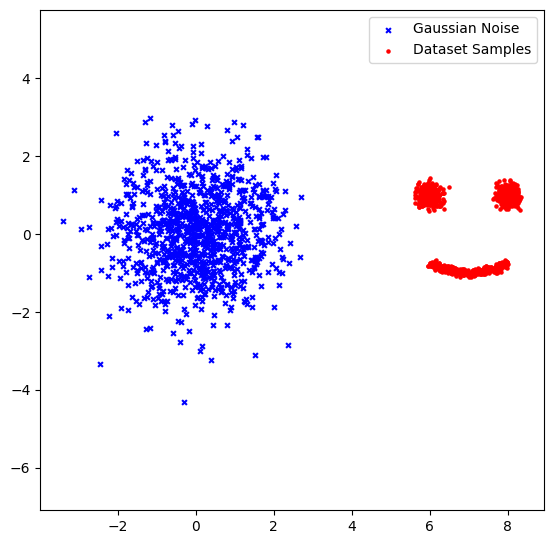

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torchcfm.models.models import *
import torch
from matplotlib.lines import Line2D

def sample_target_distribution(n):
    pts = np.zeros((n, 2))
    comps = np.random.choice(3, n)  # 0=left eye, 1=right eye, 2=mouth

    # Eyes (Gaussian blobs)
    for i, cx in [(0, 6), (1, 8)]:
        m = comps == i
        pts[m] = np.random.randn(m.sum(), 2) * 0.15 + [cx, 1]

    # Smile (arc)
    m = comps == 2
    θ = np.random.uniform(-2*np.pi/3, -np.pi/3, m.sum())
    r = 2 + 0.05*np.random.randn(m.sum())
    pts[m] = np.c_[7 + r*np.cos(θ), r*np.sin(θ) + 1]

    return pts

# Plot noise
noise = np.random.randn(1000,2)
plt.figure(figsize=(6.5, 6.5))
s1 = plt.scatter(noise[:,0], noise[:,1], marker='x', s=12, label='Gaussian Samples', c='blue')

# Create x values from -1 to 1
dataset_size = 1000
target_data = sample_target_distribution(dataset_size)
xs = target_data[:, 0]

# Calculate y values
ys = target_data[:, 1]

s2 = plt.scatter(xs, ys, label='Dataset Samples', s=5, c='red')

# Add labels
plt.legend([s1, s2], ["Gaussian Noise", "Dataset Samples"], loc="upper right")

# Show the plot
plt.axis('equal')
plt.show()

# Train Model

We will define a diffusion network as a simple MLP.  The input must be the same size as the output.

In [ ]:
# Neural network
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(dim=2, w=128, time_varying=True)
model = model.to(device)
model

MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): SELU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SELU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SELU()
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

Define a linear noise schedule.

In [ ]:
# Noise schedule
beta_start = 0.0001
beta_end = 0.02
timesteps = 1000
betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

def get_noise_schedule(t, data):

    ### CORRUPT DATA WITH NOISE ###
    noise = torch.randn_like(data).float()
    data_strength = torch.sqrt(alphas_cumprod[t])[:,None]
    noise_strength = torch.sqrt(1-alphas_cumprod[t])[:,None]
    xt = data_strength * data + noise_strength * noise
    return noise, xt
    ###############################


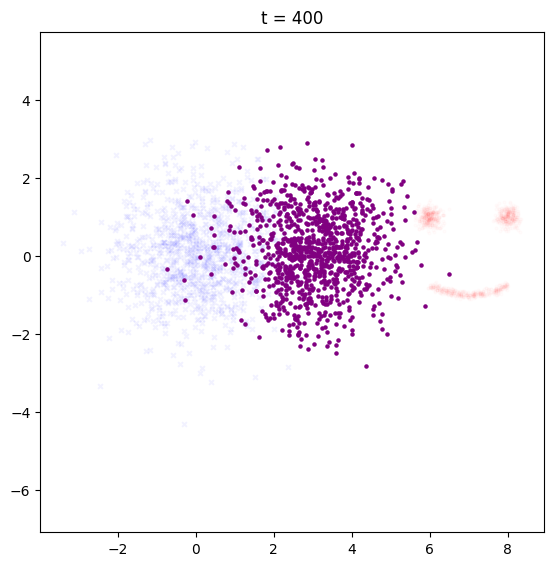

In [ ]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(noise[:,0], noise[:,1], marker='x', s=12, label='Gaussian Samples', c='blue', alpha=0.05)
plt.scatter(xs, ys, label='Dataset Samples', s=5, c='red', alpha=0.01)

#
timestep = 400
t = torch.full((target_data.shape[0],), timestep, dtype=torch.int32)
_, xt = get_noise_schedule(t, torch.tensor(target_data).to(device))
plt.scatter(xt[:,0].cpu(), xt[:,1].cpu(), label='Noisy Dataset Samples', c='purple', s=5)
plt.title(f"t = {timestep}")

# Show the plot
plt.axis('equal')
plt.show()

Now, lets define our hyperparameters.

In [ ]:
# Hyperparameters
bs = 256

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

___
### **Algorithm 2** Sampling
___
1. &nbsp;$x_T \sim \mathcal{N}(0, I)$
2. &nbsp;$\textbf{for } t=T,...,1 \textbf{ do}$
3. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\epsilon \sim \mathcal{N}(0, I) \text{ if } t>1, \text{ else } \epsilon=0$
4. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; ${x}_{t-1}=\sqrt{\alpha_{t-1}} \left( \frac{{x}_t-\sqrt{1-\alpha_t}D_{\theta}(x_t,t)}{\sqrt{\alpha_t}} \right) + \sqrt{1-\alpha_{t-1}-\sigma_t} D_{\theta}(x_t,t) + \sigma_t\epsilon$
5. &nbsp;$\textbf{end for}$
6. &nbsp;$\textbf{return } x_0$
___

In [ ]:
# Sampling
@torch.no_grad()
def sample(x, add_noise=False):

    # Inference : Markov chain with T steps
    markov_chain = torch.zeros(timesteps+1, x.shape[0], x.shape[1])
    markov_chain[0] = x
    for i in reversed(range(timesteps)):

        # Get the correct shape for timesteps t
        t = torch.full((x.shape[0],), i, dtype=torch.long).to(device)

        # Run neural network
        model_input = torch.concat([x, t[:,None] / timesteps], axis=1).float()
        predicted_noise = model(model_input)

        # Equation 12 - Denoising Diffusion Implicit Models (https://arxiv.org/pdf/2010.02502)
        alpha_cumprod = alphas_cumprod[t][:, None]
        alpha_cumprod_minus_1 = (torch.tensor(1.0) if i == 0 else alphas_cumprod[t-1][:, None])
        if add_noise == True:
            noise_scaler = 16
            sigma_t = torch.sqrt((1-alpha_cumprod_minus_1)/(1-alpha_cumprod)) * torch.sqrt(1-(alpha_cumprod/alpha_cumprod_minus_1)) / noise_scaler
        else:
            sigma_t = 0
        x = torch.sqrt(alpha_cumprod_minus_1) * ((x - torch.sqrt(1 - alpha_cumprod) * predicted_noise) / torch.sqrt(alpha_cumprod)) + \
            torch.sqrt(1 - alpha_cumprod_minus_1 - sigma_t**2) * predicted_noise + \
            sigma_t * torch.randn_like(x)
        markov_chain[timesteps - i] = x.cpu()

    return markov_chain

___
### **Algorithm 1** Training
___
1. &nbsp;$\textbf{repeat}$
2. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_0 \sim q(x_0)$
3. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $t \sim \mathcal{U}(\{1,...,T\})$
4. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\epsilon \sim \mathcal{N}(0, I)$
5. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $x_t = \sqrt{\alpha_t} x_0 + \sqrt{1-\alpha_t} \epsilon$
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\text{Take gradient step on}$
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $\nabla_\theta \|D_\theta(x_t, t) - \epsilon\|^2 $
___

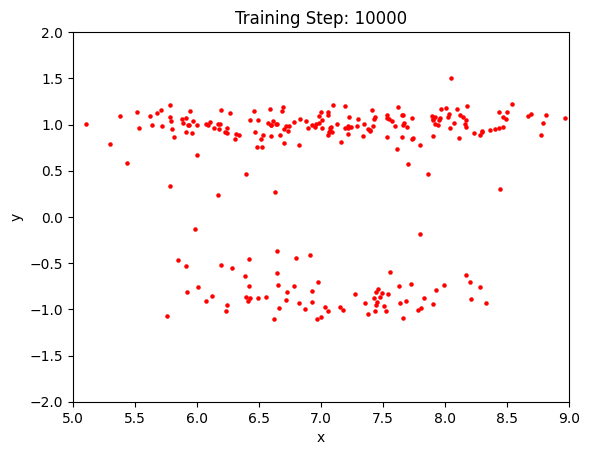

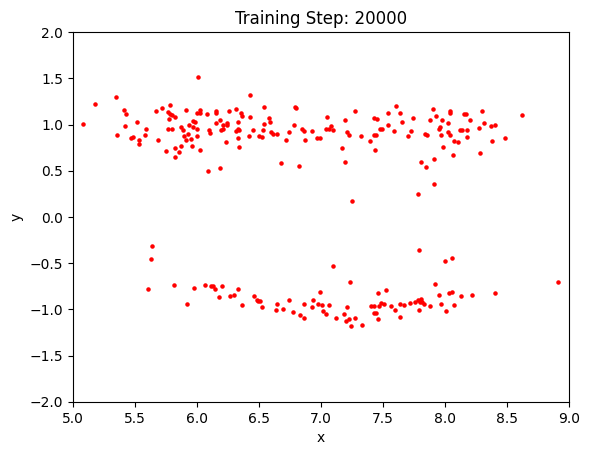

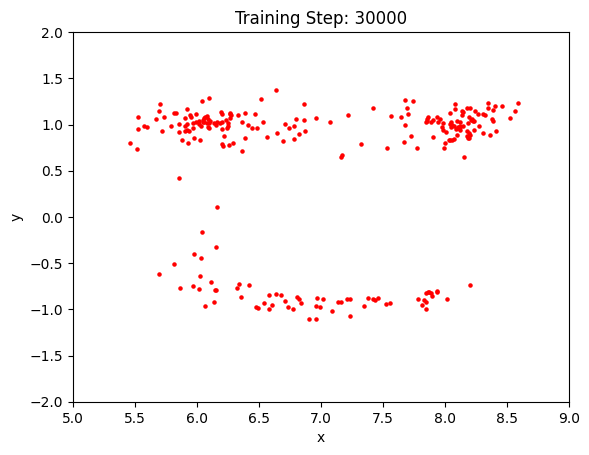

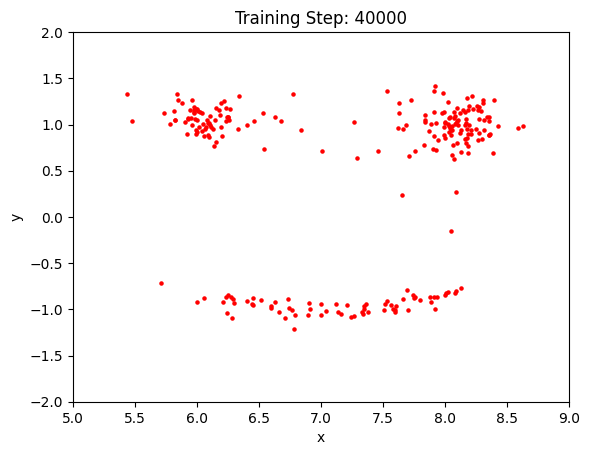

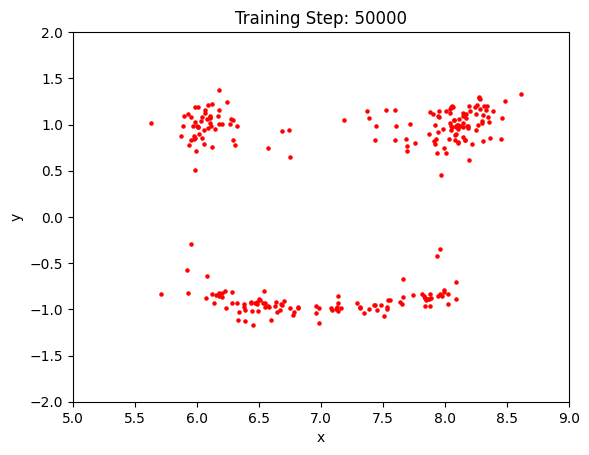

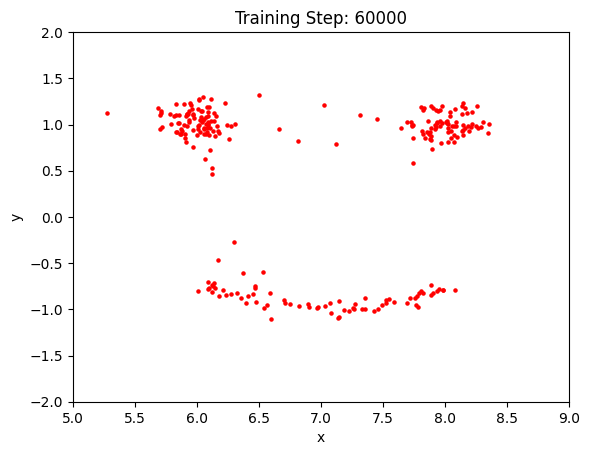

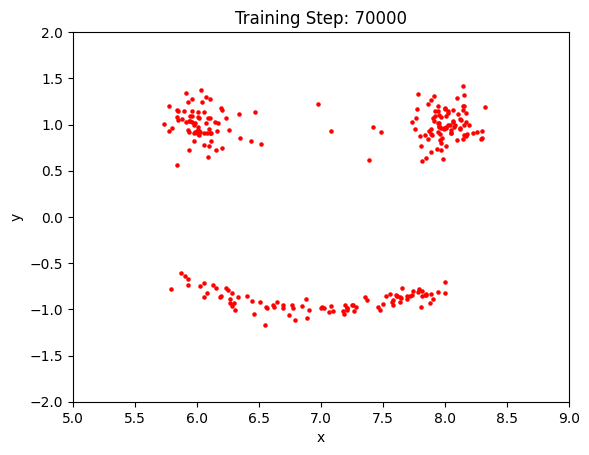

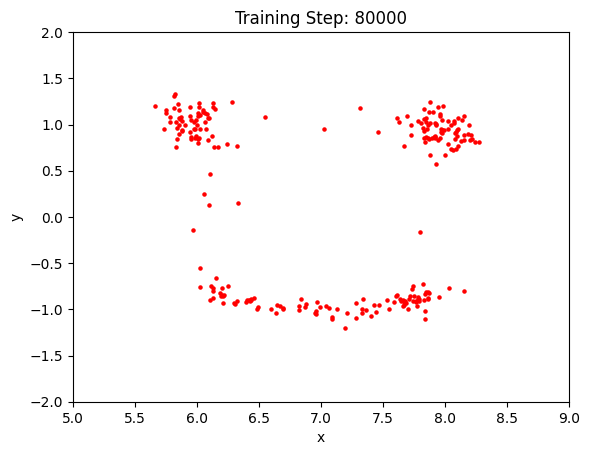

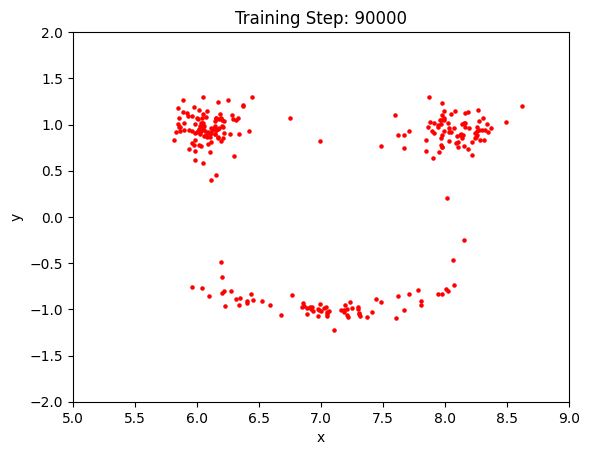

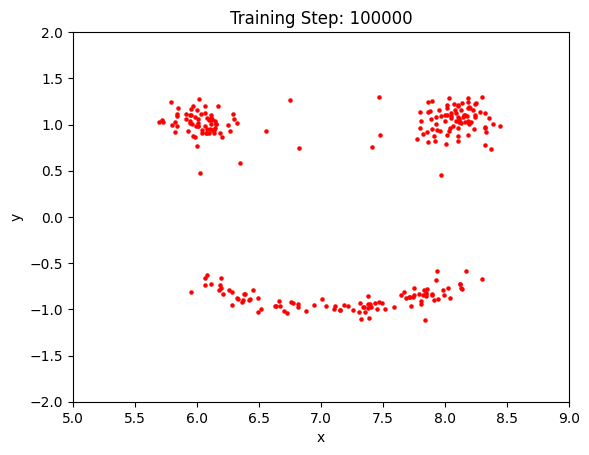

In [ ]:
for step in range(100000):

    ### FORWARD PASS ###
    # Prepare data
    data = torch.tensor(sample_target_distribution(bs)).to(device)

    # Timesteps
    t = torch.randint(0, 1000, (bs,)).to(device)

    # Corrupt with noise
    noise, noisy_data = get_noise_schedule(t, data)

    # Run neural network
    model_input = torch.concat([noisy_data, t[:,None] / timesteps], axis=1).float()
    pred_noise = model(model_input)

    # Calculate and return loss
    loss = ((pred_noise - noise) ** 2).mean()
    ####################

    # Backwards pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Log outputs every 10k steps
    if (step+1) % 10000 == 0:
        # Generate samples
        noise = torch.randn_like(data).float()
        samples = sample(noise)

        # Plot samples
        for s in range(samples.shape[1]):
            plt.scatter(samples[-1,s,0], samples[-1,s,1], c='red', s=5)

        plt.xlabel('x')
        plt.ylabel('y')
        plt.xlim(5, 9)
        plt.ylim(-2, 2)
        plt.title('Training Step: ' + str(step+1))
        plt.show()

# Inference

Now our model is trained lets compare deterministic sampling to stochastic sampling.  Deterministic sampling will produce smooth diffusion mapping, were as stochastic sampling will add a small amount of noise at every step of the diffusion process.

/tmp/ipython-input-3837501747.py:11: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([p1, s1, s2], ["Diffusion Trajectory", "$x_T$", "$x_0$", "Dataset Samples"], loc="upper right")


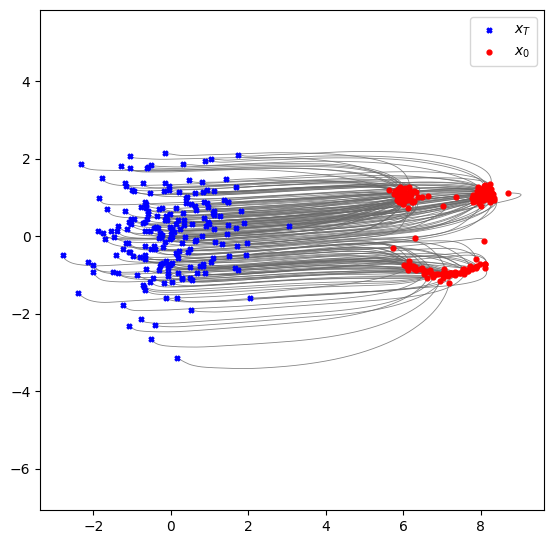

In [ ]:
# Generate samples
noise = torch.randn(200, 2).to(data.device).float()
samples = sample(noise, False)

# Plot samples
plt.figure(figsize=(6.5, 6.5))
for s in range(samples.shape[1]):
    p1 = plt.plot(samples[:,s,0], samples[:,s,1], c='dimgrey', linewidth=0.6, alpha=0.8, zorder=-1)
    s1 = plt.scatter(samples[0,s,0], samples[0,s,1], c='blue', s=12, marker='X')
    s2 = plt.scatter(samples[-1,s,0], samples[-1,s,1], c='red', s=12)
plt.legend([p1, s1, s2], ["Diffusion Trajectory", "$x_T$", "$x_0$", "Dataset Samples"], loc="upper right")
plt.axis('equal')
plt.show()


# Stable Diffusion

Stable diffusion is a general purpose diffusion model that is condition on text, allowing for text-to-image generation. In this notebook, we will look at one of the original versions of stable diffusion which is version 1.5. The model weights can be found at https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5.

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

# Download model
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
pipe

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/5 [00:00<?, ?it/s]

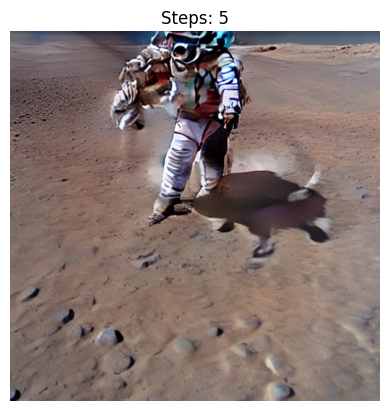

  0%|          | 0/10 [00:00<?, ?it/s]

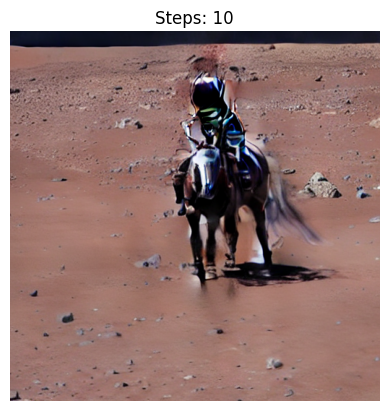

  0%|          | 0/25 [00:00<?, ?it/s]

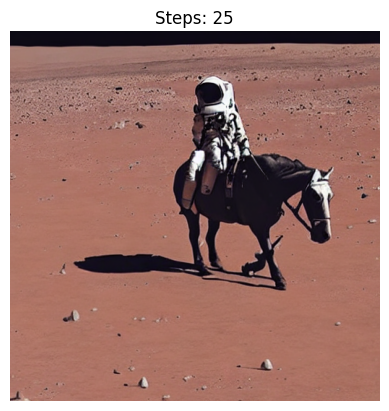

  0%|          | 0/50 [00:00<?, ?it/s]

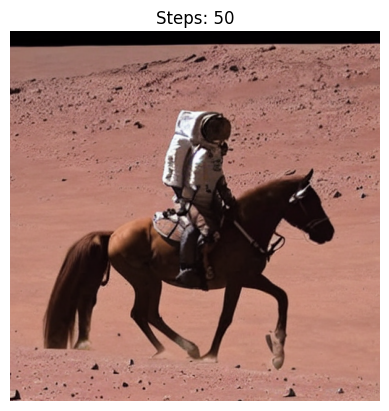

In [ ]:
# Generate image with a different number of steps
prompt = "a photo of an astronaut riding a horse on mars"

for steps in [5, 10, 25, 50]:
    image = pipe(prompt, generator=torch.manual_seed(1), num_inference_steps=steps).images[0]

    # Display image
    plt.imshow(image)
    plt.title(f"Steps: {steps}")
    plt.axis('off')
    plt.show()


# Refining Noise

This notebook goes through a simple example of aligning noise in stable diffusion 1.5.  The goal is to increase the alignment of the input text prompt and the resultant image.  We can do this simply and efficient using a linear combination of the models outputs.

In [ ]:
import random

# Set random seed for reproducability
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

Our noise aligning algorithm is as follows:

1. $n\sim \mathcal{N}(0,I)$
2. Repeat:
	1. $\nabla \log p(y|n) = \nabla \log p(n|y) - \nabla \log p(n)$
	2. $d = \text{NormClipping}(\nabla \log p(y|n))$
	3. $n = n - d + \mathcal{N}(0,0.001 \cdot I)$
	4. $n = \frac{n\sqrt{d}}{|n|}$

where $y$ is our condition (e.g. a text prompt).

In [ ]:
def align_noise(latents, prompts, device, pipe, aligning_steps=20):

    # Get latent dimensions
    b, c, w, h = latents.shape

    # Duplicate latents for CFG
    t = torch.tensor(999, device=device)
    prompt_embeds, negative_prompt_embeds = pipe.encode_prompt(prompts,device,1,True)
    prompt_embeds = torch.cat([negative_prompt_embeds, prompt_embeds])

    #  Calculate total dimension of the image
    dimensions = len(torch.flatten(latents[0]))

    for _ in range(aligning_steps):
        # Copy noise for conditional/unconditorch.flatten()tion generation
        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = pipe.scheduler.scale_model_input(latent_model_input, t)

        # Predict the noise residual
        noise_pred = pipe.unet(
            latent_model_input.half(),
            t,
            encoder_hidden_states=prompt_embeds.half(),
            return_dict=False,
        )[0]

        # Find the direction
        dir = (noise_pred[b:] - noise_pred[:b]).detach()

        # Gradient norm clipping of direction
        clip_mag = 0.5
        dir_norm = torch.norm(dir.view(-1, c * w * h), dim=1)
        mask = dir_norm > clip_mag
        dir = torch.where(
            mask[:, None, None, None],
            clip_mag * (dir / dir_norm[:, None, None, None]),
            dir
        ).view(-1, c, w, h)

        # Push the noise in a particular direction
        step_size = 1.0
        latents -= dir * step_size

        # Add a small amount of noise at every step (following arxiv:2303.13703)
        noise_level = 0.001
        latents += torch.tensor(np.random.randn(b, c, w, h), device=device).half() * np.sqrt(noise_level)

        # Normalize latent to be the expected magnitude
        latent_norms = torch.norm(latents.view(-1, c * w * h), dim=1)[:,None,None,None]
        latents = (latents / latent_norms) * np.sqrt(dimensions)

    return latents

In [ ]:
# Generate an image using Gaussian noise
set_seed(0)
prompt = "A portrait photo of a happy face"
latents = torch.randn((1, pipe.unet.in_channels, 512 // pipe.vae_scale_factor, 512 // pipe.vae_scale_factor), device=device).half()
starting_noise = latents.clone()
with torch.no_grad():
    img_before = pipe(prompt, num_inference_steps=20, latents=latents, guidance_scale=1.0).images[0]

/tmp/ipython-input-4071606773.py:4: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latents = torch.randn((1, pipe.unet.in_channels, 512 // pipe.vae_scale_factor, 512 // pipe.vae_scale_factor), device=device).half()


  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# Align noise, then sample an image with that aligned noise
with torch.no_grad():
    aligning_steps = 20
    aligned_latents = align_noise(latents, prompt, device, pipe, aligning_steps)
    img_after = pipe(prompt, num_inference_steps=20, latents=aligned_latents, guidance_scale=1.0).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

Text(0.5, 0.98, 'PROMPT: "A portrait photo of a happy face"')

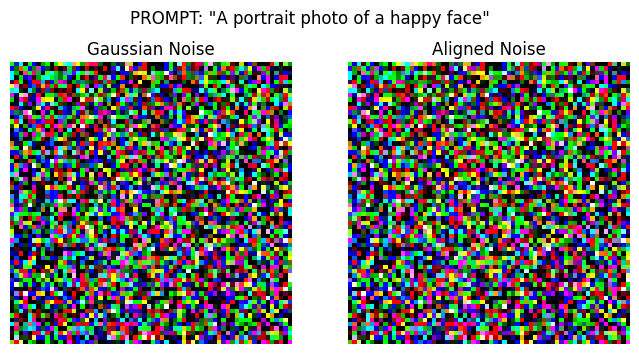

In [ ]:
# Display generated images
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(np.transpose(starting_noise.float().cpu().numpy()[0,:3], (1,2,0)) )
axs[0].set_title("Gaussian Noise")
axs[0].axis('off')
axs[1].imshow(np.transpose(aligned_latents.float().cpu().numpy()[0,:3], (1,2,0)))
axs[1].set_title("Aligned Noise")
axs[1].axis('off')
fig.suptitle("PROMPT: " + "\"" + prompt + "\"")

Text(0.5, 0.98, 'PROMPT: "A portrait photo of a happy face"')

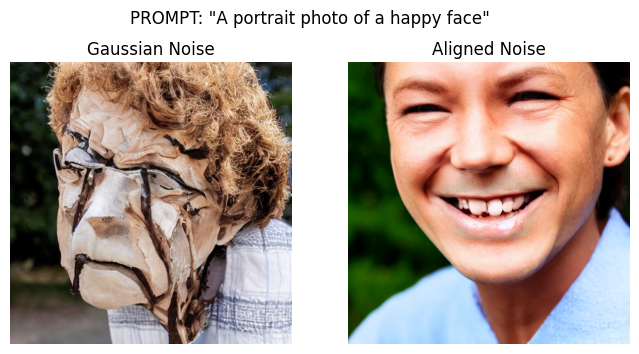

In [ ]:
# Display generated images
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].set_title("Gaussian Noise")
axs[0].axis('off')
axs[1].imshow(img_after)
axs[1].set_title("Aligned Noise")
axs[1].axis('off')
fig.suptitle("PROMPT: " + "\"" + prompt + "\"")